In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import PIL

from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix

import os
from pathlib import Path
import random
from collections import OrderedDict
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchvision.models import vit_b_16, ViT_B_16_Weights


In [26]:
IMAGE_PATH = Path("/Users/devayushrout/Desktop/MedWaste Guardian/dataset")

IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*/*.jpg"))
print(f'Total Images = {len(IMAGE_PATH_LIST)}')

Total Images = 6156


In [27]:
CLASSES = os.listdir(IMAGE_PATH)
CLASSES = sorted(CLASSES)

print(f"Total Classes = {len(CLASSES)}:\n")
for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    print(f'* {label}: {len(total_images_class)} images')

Total Classes = 12:

* (BT) Body Tissue or Organ: 474 images
* (GE) Glass equipment-packaging 551: 551 images
* (ME) Metal equipment -packaging: 426 images
* (OW) Organic wastes: 583 images
* (PE) Plastic equipment-packaging: 558 images
* (PP) Paper equipment-packaging: 457 images
* (SN) Syringe needles: 513 images
* Gauze: 510 images
* Gloves: 543 images
* Mask: 529 images
* Syringe: 473 images
* Tweezers: 539 images


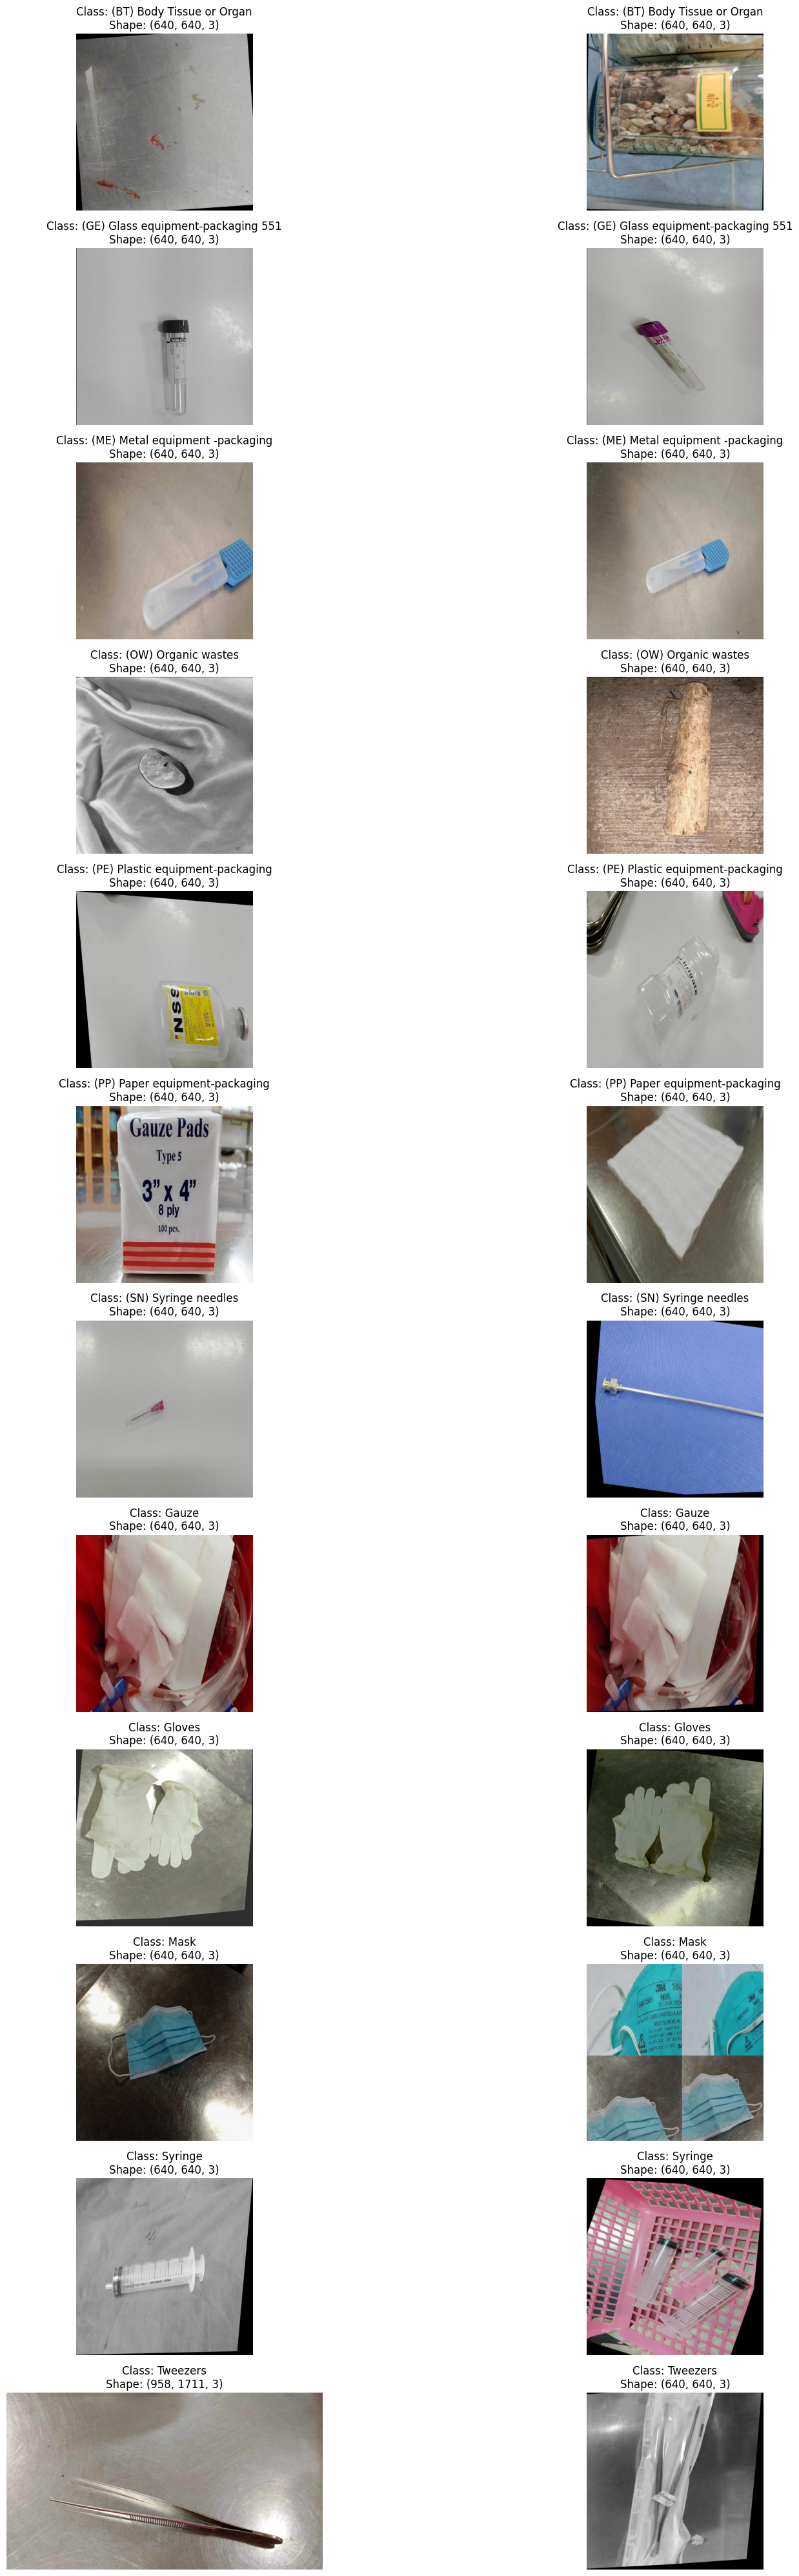

In [28]:
NUM_IMAGES = 2

fig,ax = plt.subplots(nrows = len(CLASSES), ncols = NUM_IMAGES, figsize = (20,40))

p = 0

for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    total_selected = random.choices(total_images_class, k = NUM_IMAGES)
    
    for i,img_path in enumerate(total_selected):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[p,i].imshow(img_rgb)
        ax[p,i].axis('off')
        ax[p,i].set_title(f'Class: {label}\nShape: {img_rgb.shape}')
        
    p += 1
    
fig.tight_layout()
fig.show()

In [29]:
images_path_train = list()
labels_train = list()

images_path_test = list()
labels_test = list()

for i in IMAGE_PATH_LIST:
    if i.parent.stem == 'Train images':
        images_path_train.append(i)
        labels_train.append(i.parent.parent.stem)
        
    else:
        images_path_test.append(i)
        labels_test.append(i.parent.parent.stem)

In [30]:
data_train = pd.DataFrame({'Image':images_path_train, 'Label':labels_train})
data_train.head()

,Image,Label
0,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
1,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
2,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
3,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
4,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes


In [31]:
data_testing = pd.DataFrame({'Image':images_path_test, 'Label':labels_test})
data_testing.head()

,Image,Label
0,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
1,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
2,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
3,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
4,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes


In [32]:
SEED = 42

data_training, data_validation = tts(data_train, test_size = 0.3, random_state = SEED, 
                                    shuffle = True)

print(data_training.shape), print(data_validation.shape)

(3432, 2)
(1471, 2)


(None, None)

In [33]:
label2id = dict(zip(CLASSES, range(len(CLASSES))))
label2id

{'(BT) Body Tissue or Organ': 0,
 '(GE) Glass equipment-packaging 551': 1,
 '(ME) Metal equipment -packaging': 2,
 '(OW) Organic wastes': 3,
 '(PE) Plastic equipment-packaging': 4,
 '(PP) Paper equipment-packaging': 5,
 '(SN) Syringe needles': 6,
 'Gauze': 7,
 'Gloves': 8,
 'Mask': 9,
 'Syringe': 10,
 'Tweezers': 11}

In [34]:
class CustomImageDataset(Dataset):
    def __init__(self, data:pd.DataFrame, label_map:dict, transforms):
        self.data = data
        self.label_map = label_map
        self.transforms = transforms
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        data_new = self.data.copy()
        data_new['Label'] = data_new['Label'].map(self.label_map)
        
        image_path = data_new.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        image = self.transforms(image)
        
        label = data_new.iloc[idx, 1]
        
        return image,label

In [35]:
weights = ViT_B_16_Weights.DEFAULT
image_transforms = weights.transforms()
image_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [36]:
train_dataset = CustomImageDataset(data_training, label2id, image_transforms)

val_dataset = CustomImageDataset(data_validation, label2id, image_transforms)

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataloader = DataLoader(dataset = train_dataset, batch_size = BATCH_SIZE, 
                            shuffle = True, num_workers = NUM_WORKERS)

val_dataloader = DataLoader(dataset = val_dataset, batch_size = BATCH_SIZE, 
                            shuffle = True, num_workers = NUM_WORKERS)

In [ ]:
batch_images, batch_labels = next(iter(train_dataloader))

batch_images.shape, batch_labels.shape

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'CustomImageDataset' on <module '__main__' (built-in)>


In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

In [ ]:
model = vit_b_16(weights = weights)

In [ ]:
summary(model = model, input_size = [32, 3, 224, 224], col_width = 15, 
        col_names = ['input_size', 'output_size', 'num_params', 'trainable'], 
        row_settings = ['var_names'])

In [ ]:
for param in model.conv_proj.parameters():
    param.requires_grad = False
    
for param in model.encoder.parameters():
    param.requires_grad = False

In [ ]:
summary(model = model, input_size = [32, 3, 224, 224], col_width = 15, 
        col_names = ['input_size', 'output_size', 'num_params', 'trainable'], 
        row_settings = ['var_names'])

In [ ]:
output_shape = len(CLASSES)

model.heads = nn.Sequential(OrderedDict([('head', nn.Linear(in_features = 768, out_features = output_shape))]))

In [ ]:
# We view one last time to check if they were modified correctly.
summary(model = model, input_size = [32, 3, 224, 224], col_width = 15, 
        col_names = ['input_size', 'output_size', 'num_params', 'trainable'], 
        row_settings = ['var_names'])

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01, weight_decay = 0.0001)

In [ ]:
class EarlyStopping:
    def __init__(self, patience:int = 10, delta:float = 0.0001, path:str = "best_model.pth"):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.best_score = None
        self.counter = 0
        self.early_stop = False
        
    def __call__(self, val_loss, model):
        if self.best_score is None:
            self.best_score = val_loss
            self.save_checkpoint(model)
            
        elif val_loss > self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                
        else:
            self.best_score = val_loss
            self.save_checkpoint(model)
            self.counter = 0
            
    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [ ]:
early_stopping = EarlyStopping(patience = 20, delta = 0.)


In [ ]:
def train_step(model:torch.nn.Module, dataloader:torch.utils.data.DataLoader, 
            loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer):
    
    model.train()
    
    train_loss = 0
    train_accuracy = 0
    
    for batch,(X,y) in enumerate(dataloader):
        X = X.to(device = DEVICE, dtype = torch.float32)
        y = y.to(device = DEVICE, dtype = torch.long)
        
        optimizer.zero_grad()
        
        y_pred_logit = model(X)
        loss = loss_fn(y_pred_logit, y)
        train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
        y_pred_prob = y_pred_logit.softmax(dim = 1)
        y_pred_class = y_pred_prob.argmax(dim = 1)
        train_accuracy += balanced_accuracy_score(y.cpu().numpy(), y_pred_class.detach().cpu().numpy())
        
        train_loss = train_loss / len(dataloader)
    train_accuracy = train_accuracy / len(dataloader)
    
    return train_loss, train_accuracy


In [ ]:
def val_step(model:torch.nn.Module, 
             dataloader:torch.utils.data.DataLoader, 
             loss_fn:torch.nn.Module):
    
    model.eval()
    
    val_loss = 0
    val_accuracy = 0
    
    with torch.inference_mode():
        for batch,(X,y) in enumerate(dataloader):
            X = X.to(device = DEVICE, dtype = torch.float32)
            y = y.to(device = DEVICE, dtype = torch.long)
            
            y_pred_logit = model(X)
            loss = loss_fn(y_pred_logit, y)
            val_loss += loss.item()
            
            y_pred_prob = y_pred_logit.softmax(dim = 1)
            y_pred_class = y_pred_prob.argmax(dim = 1)
            val_accuracy += balanced_accuracy_score(y.cpu().numpy(), 
                                                    y_pred_class.detach().cpu().numpy())
            
    val_loss = val_loss / len(dataloader)
    val_accuracy = val_accuracy / len(dataloader)
    
    return val_loss, val_accuracy

In [ ]:
def train(model:torch.nn.Module, train_dataloader:torch.utils.data.DataLoader, 
          val_datalaoder:torch.utils.data.DataLoader, loss_fn:torch.nn.Module, 
          optimizer:torch.optim.Optimizer, early_stopping, epochs:int = 10):
    
    results = {'train_loss':[], 'train_accuracy':[], 'val_loss':[], 'val_accuracy':[]}
    
    for epoch in tqdm(range(epochs)):
        
        train_loss, train_accuracy = train_step(model = model, dataloader = train_dataloader, 
                                                loss_fn = loss_fn, optimizer = optimizer)
        
        val_loss, val_accuracy = val_step(model = model, dataloader = val_dataloader, 
                                          loss_fn = loss_fn)
        
        print(f'Epoch: {epoch + 1} | ', 
              f'Train Loss: {train_loss:.4f} | ', 
              f'Train Accuracy: {train_accuracy:.4f} | ', 
              f'Val Loss: {val_loss:.4f} | ', 
              f'Val Accuracy: {val_accuracy:.4f}')
        
        early_stopping(val_loss, model)
        
        if early_stopping.early_stop == True:
            print("Early Stopping!!")
            break
        
        results['train_loss'].append(train_loss)
        results['train_accuracy'].append(train_accuracy)
        results['val_loss'].append(val_loss)
        results['val_accuracy'].append(val_accuracy)
        
    return results
            

In [ ]:
# Training !!!

EPOCHS = 100

torch.cuda.manual_seed(SEED)
torch.manual_seed(SEED)

RESULTS = train(model.to(device = DEVICE), train_dataloader, val_dataloader, loss_fn, optimizer, early_stopping, EPOCHS)

In [ ]:
def metric_and_loss_plot(results:dict):
    
    training_loss = results['train_loss']
    training_accuracy = results['train_accuracy']
    
    valid_loss = results['val_loss']
    valid_accuracy = results['val_accuracy']
    
    fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
    ax = ax.flat
    
    ax[0].plot(training_loss, color = "red")
    ax[0].plot(valid_loss, color = "blue")
    ax[0].set_title("CrossEntropyLoss", fontsize = 12, fontweight = "bold", color = "black")
    ax[0].set_xlabel("Epoch", fontsize = 10, fontweight = "bold", color = "black")
    ax[0].set_ylabel("loss", fontsize = 10, fontweight = "bold", color = "black")
    
    ax[1].plot(training_accuracy, color = "red")
    ax[1].plot(valid_accuracy, color = "blue")
    ax[1].set_title("Balanced Accuracy", fontsize = 12, fontweight = "bold", color = "black")
    ax[1].set_xlabel("Epoch", fontsize = 10, fontweight = "bold", color = "black")
    ax[1].set_ylabel("score", fontsize = 10, fontweight = "bold", color = "black")
    
    fig.tight_layout()
    fig.show()

In [ ]:
metric_and_loss_plot(RESULTS)


In [ ]:
def predictions(test_dataloader:torch.utils.data.DataLoader):
    
    checkpoint = torch.load("best_model.pth")
    
    loaded_model = vit_b_16()
    
    loaded_model.heads = nn.Sequential(OrderedDict([('head', nn.Linear(in_features = 768, 
                                                                    out_features = output_shape))]))
    
    loaded_model.load_state_dict(checkpoint)
    
    loaded_model.to(device = DEVICE)
    
    loaded_model.eval()
    
    y_pred_test = []
    
    with torch.inference_mode():
        
        for X,_ in tqdm(test_dataloader):
            X = X.to(device = DEVICE, dtype = torch.float32)
            y_pred_logit = loaded_model(X)
            y_pred_prob = y_pred_logit.softmax(dim = 1)
            y_pred_class = y_pred_prob.argmax(dim = 1)
            y_pred_test.append(y_pred_class.detach().cpu())
            
    y_pred_test = torch.cat(y_pred_test)
    
    return y_pred_test


In [ ]:
# We create our Dataset and DataLoader.
test_dataset = CustomImageDataset(data_testing, label2id, image_transforms)

test_dataloader = DataLoader(dataset = test_dataset, batch_size = BATCH_SIZE, 
                            shuffle = False, num_workers = NUM_WORKERS)

In [ ]:
# We make the predictions.
y_pred_test = predictions(test_dataloader)

In [ ]:
test_accuracy = balanced_accuracy_score(data_testing['Label'].map(label2id), y_pred_test.numpy())

print(f"Balanced Accuracy Test = {test_accuracy:.4f}")

In [ ]:
cf_mx_test = confusion_matrix(data_testing['Label'].map(label2id), y_pred_test.numpy())

fig,ax = plt.subplots(figsize = (10,10))
sns.heatmap(cf_mx_test, cmap = 'Reds', fmt = ' ', annot = True, cbar = False, square = True, linewidths = 0.4,
            xticklabels = CLASSES, yticklabels = CLASSES, ax = ax)
ax.set_ylabel("True", color = "darkblue", fontsize = 12, fontweight = "bold")
ax.set_xlabel("Predicted", color = "darkblue", fontsize = 12, fontweight = "bold")
ax.set_title("Confusion Matrix Test", fontsize = 14, fontweight = "bold", color = "black")

fig.show()